# Drone Battery Performance Analysis (Upgraded)

Mission telemetry (battery %, voltage, temperature) over a 60-minute flight, checked against operating thresholds and visualized with matplotlib.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Input data

In [2]:
# Drone Battery Performance Data
time = np.array([0, 10, 20, 30, 40, 50, 60])
battery = np.array([100, 94, 87, 79, 68, 54, 38])
voltage = np.array([12.6, 12.4, 12.2, 12.0, 11.8, 11.5, 11.2])
temperature = np.array([30, 32, 35, 39, 43, 47, 52])

# Operating thresholds
BATTERY_LOW = 60        # %
BATTERY_CRITICAL = 40   # %
TEMP_HIGH = 45          # deg C
TEMP_CRITICAL = 50      # deg C
VOLTAGE_LOW = 11.5      # V

print("Time (minutes):", time)
print("Battery (%):", battery)
print("Voltage (V):", voltage)
print("Temperature (C):", temperature)


Time (minutes): [ 0 10 20 30 40 50 60]
Battery (%): [100  94  87  79  68  54  38]
Voltage (V): [12.6 12.4 12.2 12.  11.8 11.5 11.2]
Temperature (C): [30 32 35 39 43 47 52]


## Basic statistics

Named the thresholds above (instead of hardcoding 40/60/45/50/11.5 inline later) so they're defined once and reused consistently across every check and plot.

In [3]:
print("BATTERY ANALYSIS")
print("Average Battery:", np.mean(battery), "%")
print("Maximum Battery:", np.max(battery), "%")
print("Minimum Battery:", np.min(battery), "%")
print("\nAverage Voltage:", np.mean(voltage), "V")
print("Average Temperature:", np.mean(temperature), "C")


BATTERY ANALYSIS
Average Battery: 74.28571428571429 %
Maximum Battery: 100 %
Minimum Battery: 38 %

Average Voltage: 11.957142857142857 V
Average Temperature: 39.714285714285715 C


## Battery drop per interval

In [4]:
battery_drop = battery[:-1] - battery[1:]
interval_labels = [f"{time[i]}-{time[i+1]}" for i in range(len(time) - 1)]

print("Battery Drop Every 10 Minutes:")
print(battery_drop)
print("Average Battery Drop:", np.mean(battery_drop), "%")


Battery Drop Every 10 Minutes:
[ 6  7  8 11 14 16]
Average Battery Drop: 10.333333333333334 %


## Threshold filters and status checks

In [5]:
print("Battery Below 50%:", battery[battery < 50])
print("High Temperature (>45C):", temperature[temperature > 45])
print("Low Voltage (<11.5V):", voltage[voltage < 11.5])


Battery Below 50%: [38]
High Temperature (>45C): [47 52]
Low Voltage (<11.5V): [11.2]


In [6]:
if battery[-1] < BATTERY_CRITICAL:
    battery_status = "Battery Critical"
elif battery[-1] < BATTERY_LOW:
    battery_status = "Battery Low"
else:
    battery_status = "Battery Healthy"

temp_status = "Temperature Warning" if np.max(temperature) > TEMP_CRITICAL else "Temperature Normal"

print(battery_status)
print(temp_status)


Battery Critical
Temperature Warning


## Mission report

In [7]:
print("\n========== DRONE BATTERY REPORT ==========")
print(f"Mission Duration      : {time[-1]} minutes")
print(f"Initial Battery       : {battery[0]} %")
print(f"Remaining Battery     : {battery[-1]} %")
print(f"Battery Consumed      : {battery[0]-battery[-1]} %")
print(f"Average Battery Drop  : {np.mean(battery_drop):.2f} %")
print(f"Maximum Temperature   : {np.max(temperature)} C")
print(f"Minimum Voltage       : {np.min(voltage)} V")
print("\nMission Analysis Completed")



========== DRONE BATTERY REPORT ==========
Mission Duration      : 60 minutes
Initial Battery       : 100 %
Remaining Battery     : 38 %
Battery Consumed      : 62 %
Average Battery Drop  : 10.33 %
Maximum Temperature   : 52 C
Minimum Voltage       : 11.2 V

Mission Analysis Completed


## Plots

Shared style settings for all figures below.

In [8]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

GREEN = "#2E7D32"
RED = "#C62828"
BLUE = "#1565C0"
ORANGE = "#EF6C00"
PURPLE = "#6A1B9A"
GRAY = "#616161"


### 1. Telemetry dashboard
Battery, voltage, and temperature over the mission, stacked on a shared time axis. Points are colored by status (healthy / low-or-high / critical) at that moment.

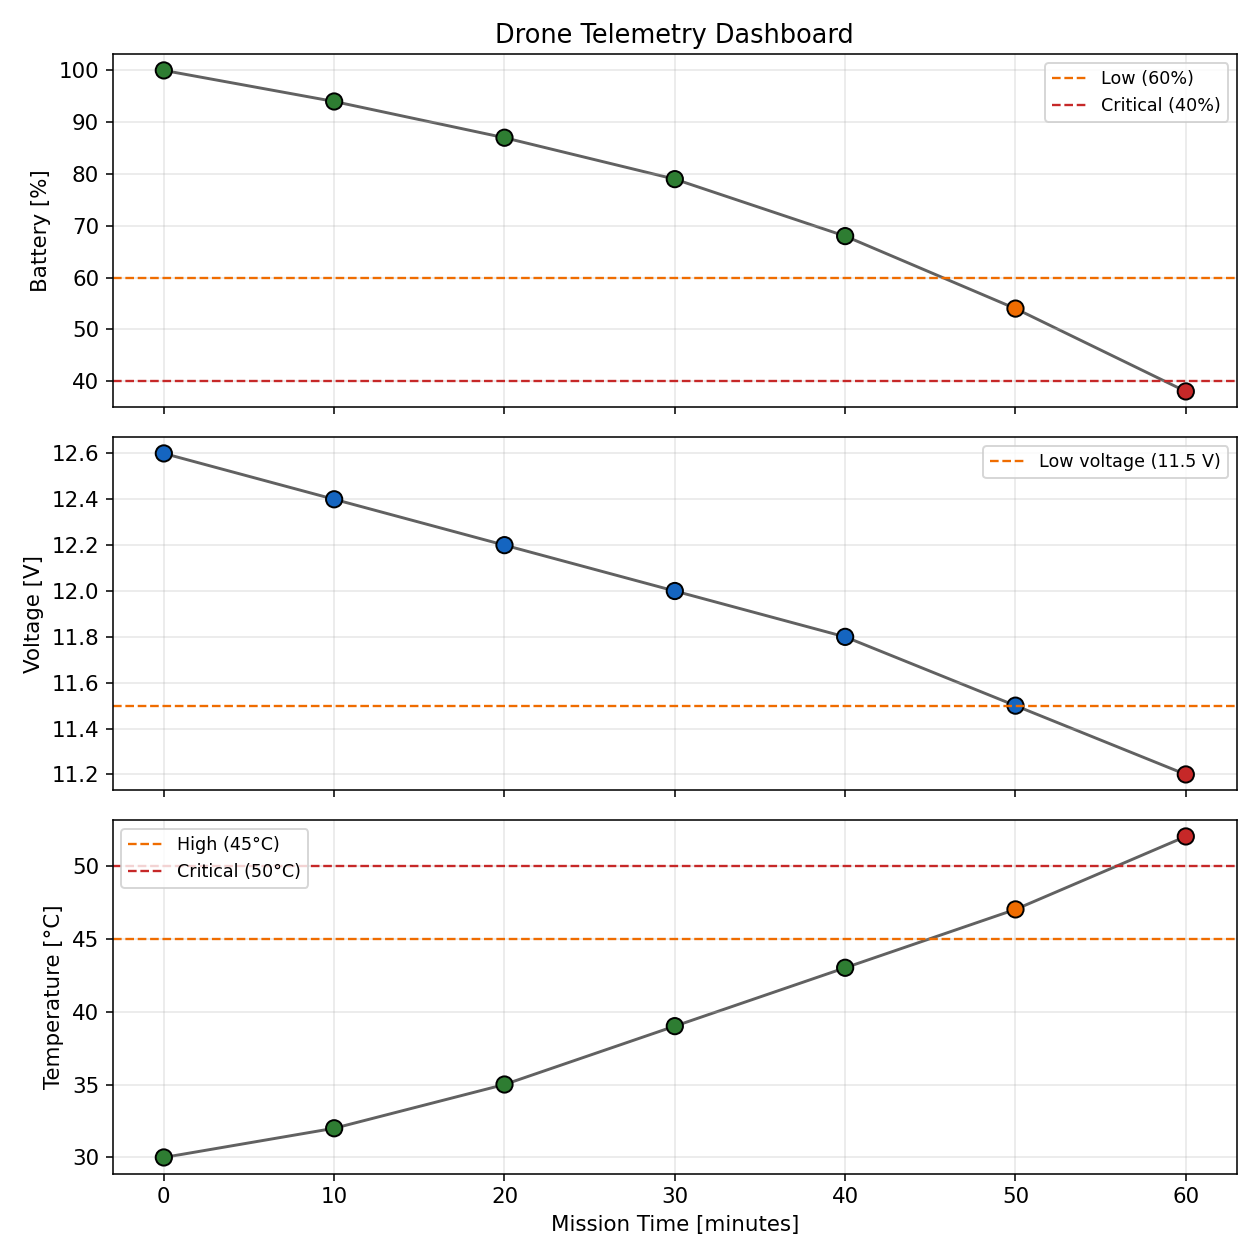

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

ax = axes[0]
point_colors = [RED if b < BATTERY_CRITICAL else (ORANGE if b < BATTERY_LOW else GREEN) for b in battery]
ax.plot(time, battery, color=GRAY, linewidth=1.5, zorder=1)
ax.scatter(time, battery, c=point_colors, s=70, edgecolor="black", zorder=2)
ax.axhline(BATTERY_LOW, color=ORANGE, linestyle="--", linewidth=1.2, label=f"Low ({BATTERY_LOW}%)")
ax.axhline(BATTERY_CRITICAL, color=RED, linestyle="--", linewidth=1.2, label=f"Critical ({BATTERY_CRITICAL}%)")
ax.set_ylabel("Battery [%]")
ax.set_title("Drone Telemetry Dashboard")
ax.legend(loc="upper right", fontsize=9)

ax = axes[1]
point_colors = [RED if v < VOLTAGE_LOW else BLUE for v in voltage]
ax.plot(time, voltage, color=GRAY, linewidth=1.5, zorder=1)
ax.scatter(time, voltage, c=point_colors, s=70, edgecolor="black", zorder=2)
ax.axhline(VOLTAGE_LOW, color=ORANGE, linestyle="--", linewidth=1.2, label=f"Low voltage ({VOLTAGE_LOW} V)")
ax.set_ylabel("Voltage [V]")
ax.legend(loc="upper right", fontsize=9)

ax = axes[2]
point_colors = [RED if t > TEMP_CRITICAL else (ORANGE if t > TEMP_HIGH else GREEN) for t in temperature]
ax.plot(time, temperature, color=GRAY, linewidth=1.5, zorder=1)
ax.scatter(time, temperature, c=point_colors, s=70, edgecolor="black", zorder=2)
ax.axhline(TEMP_HIGH, color=ORANGE, linestyle="--", linewidth=1.2, label=f"High ({TEMP_HIGH}\u00b0C)")
ax.axhline(TEMP_CRITICAL, color=RED, linestyle="--", linewidth=1.2, label=f"Critical ({TEMP_CRITICAL}\u00b0C)")
ax.set_ylabel("Temperature [\u00b0C]")
ax.set_xlabel("Mission Time [minutes]")
ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
plt.show()


### 2. Battery drain rate per interval

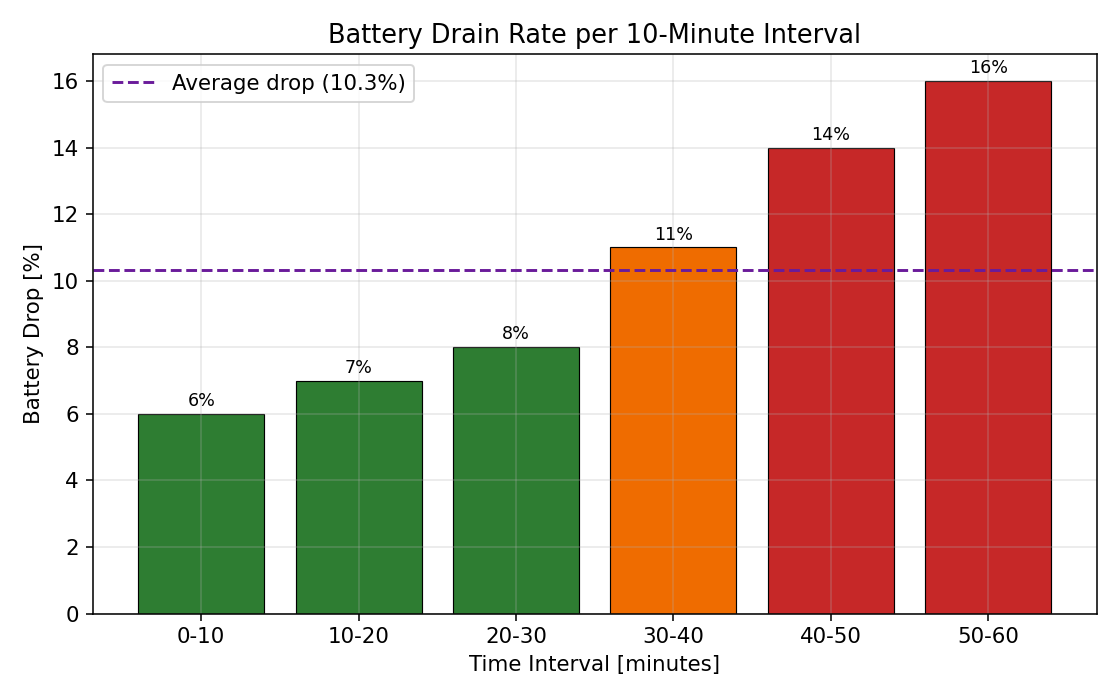

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = [RED if d >= 14 else (ORANGE if d >= 10 else GREEN) for d in battery_drop]
bars = ax.bar(interval_labels, battery_drop, color=colors, edgecolor="black", linewidth=0.6)
ax.axhline(np.mean(battery_drop), color=PURPLE, linestyle="--", linewidth=1.5,
           label=f"Average drop ({np.mean(battery_drop):.1f}%)")
for bar, val in zip(bars, battery_drop):
    ax.annotate(f"{val}%", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9)
ax.set_xlabel("Time Interval [minutes]")
ax.set_ylabel("Battery Drop [%]")
ax.set_title("Battery Drain Rate per 10-Minute Interval")
ax.legend()
fig.tight_layout()
plt.show()


### 3. Battery vs. temperature correlation
Points colored by mission time (dark = start, bright yellow = end) show how battery level falls as temperature climbs over the flight.

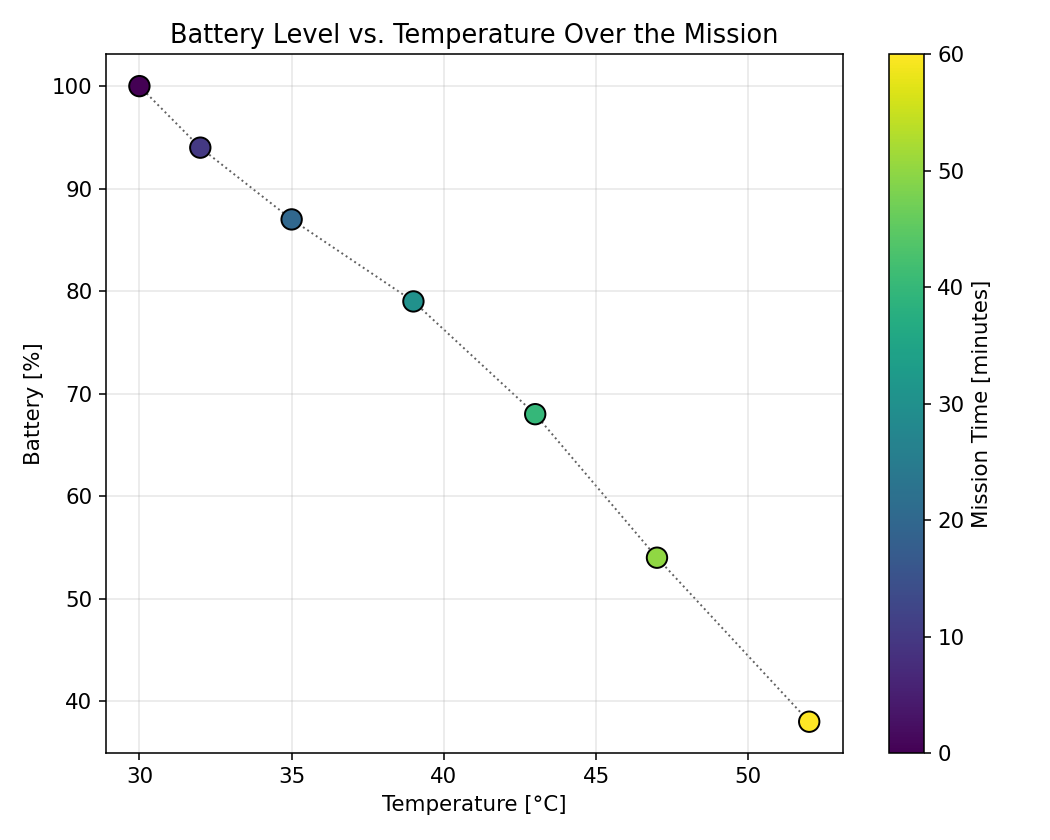

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 6))
sc = ax.scatter(temperature, battery, c=time, cmap="viridis", s=110, edgecolor="black", zorder=3)
ax.plot(temperature, battery, color=GRAY, linewidth=1, linestyle=":", zorder=1)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Mission Time [minutes]")
ax.set_xlabel("Temperature [\u00b0C]")
ax.set_ylabel("Battery [%]")
ax.set_title("Battery Level vs. Temperature Over the Mission")
fig.tight_layout()
plt.show()


### 4. End-of-mission summary vs. thresholds

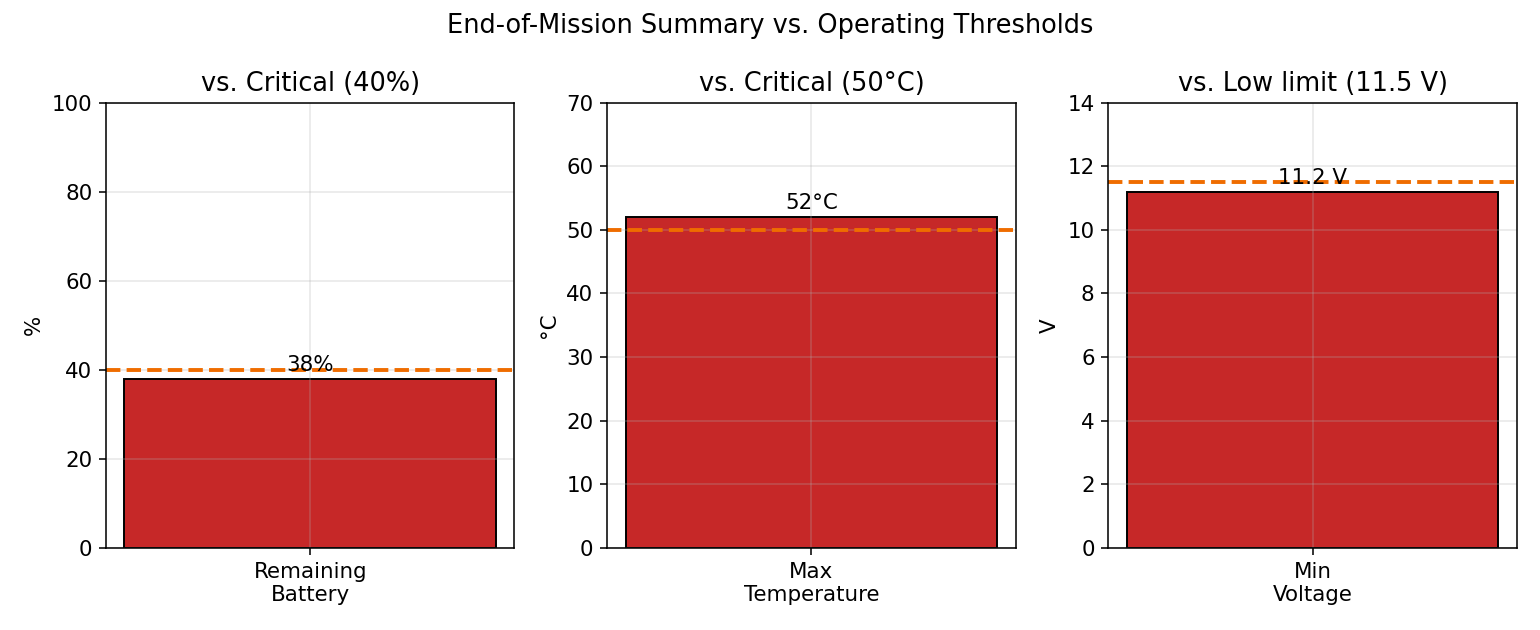

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4.5))

ax = axes[0]
val, lim = battery[-1], BATTERY_CRITICAL
color = RED if val < lim else GREEN
ax.bar(["Remaining\nBattery"], [val], color=color, edgecolor="black", width=0.5)
ax.axhline(lim, color=ORANGE, linestyle="--", linewidth=2)
ax.annotate(f"{val}%", (0, val), textcoords="offset points", xytext=(0, 4), ha="center")
ax.set_ylim(0, 100)
ax.set_ylabel("%")
ax.set_title(f"vs. Critical ({lim}%)")

ax = axes[1]
val, lim = np.max(temperature), TEMP_CRITICAL
color = RED if val > lim else GREEN
ax.bar(["Max\nTemperature"], [val], color=color, edgecolor="black", width=0.5)
ax.axhline(lim, color=ORANGE, linestyle="--", linewidth=2)
ax.annotate(f"{val}\u00b0C", (0, val), textcoords="offset points", xytext=(0, 4), ha="center")
ax.set_ylim(0, 70)
ax.set_ylabel("\u00b0C")
ax.set_title(f"vs. Critical ({lim}\u00b0C)")

ax = axes[2]
val, lim = np.min(voltage), VOLTAGE_LOW
color = RED if val < lim else GREEN
ax.bar(["Min\nVoltage"], [val], color=color, edgecolor="black", width=0.5)
ax.axhline(lim, color=ORANGE, linestyle="--", linewidth=2)
ax.annotate(f"{val} V", (0, val), textcoords="offset points", xytext=(0, 4), ha="center")
ax.set_ylim(0, 14)
ax.set_ylabel("V")
ax.set_title(f"vs. Low limit ({lim} V)")

fig.suptitle("End-of-Mission Summary vs. Operating Thresholds")
fig.tight_layout()
plt.show()
